## import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torchvision import transforms
from PIL import Image
import time
import matplotlib.pyplot as plt

In [2]:
class CNNNet(nn.Module):
    def __init__(self, num_classes=10):  # Fashion MNIST has 10 classes
        super(CNNNet, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1),  # Changed input channels to 1, no RGB here
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.classifier = nn.Sequential(
            nn.Linear(256 * 3 * 3, 512),  # Adjusted based on final feature map size
            nn.ReLU(),
            nn.Dropout(),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

In [3]:
cnnnet = CNNNet()

In [4]:
def train(model, optimizer, loss_fn, train_loader, val_loader, epochs=20, device="cpu"):
    train_losses = []
    val_losses = []
    accuracies = []

    for epoch in range(epochs):
        training_loss = 0.0
        valid_loss = 0.0
        model.train()

        for batch in train_loader:
            optimizer.zero_grad()
            inputs, targets = batch
            inputs, targets = inputs.to(device), targets.to(device)

            # Forward pass
            output = model(inputs)
            loss = loss_fn(output, targets)
            loss.backward()
            optimizer.step()

            training_loss += loss.item() * inputs.size(0)

        training_loss /= len(train_loader.dataset)
        train_losses.append(training_loss)

        model.eval()
        num_correct = 0
        num_examples = 0

        with torch.no_grad():
            for batch in val_loader:
                inputs, targets = batch
                inputs, targets = inputs.to(device), targets.to(device)

                output = model(inputs)
                loss = loss_fn(output, targets)

                valid_loss += loss.item() * inputs.size(0)

                _, predicted = torch.max(output, dim=1)
                num_correct += (predicted == targets).sum().item()
                num_examples += targets.size(0)

        valid_loss /= len(val_loader.dataset)
        val_losses.append(valid_loss)

        accuracy = (num_correct / num_examples) * 100
        accuracies.append(accuracy)

        print(f"Epoch {epoch + 1}/{epochs} | Training Loss: {training_loss:.2f} | Validation Loss: {valid_loss:.2f} | Accuracy: {accuracy:.2f}%")

    return train_losses, val_losses, accuracies

In [5]:
# Define Transformations for Fashion MNIST
img_transforms = transforms.Compose([
    transforms.Resize((28, 28)),  # Optional, as Fashion MNIST is already 28x28
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])  # Adjusted for grayscale images
])

# Load Fashion MNIST dataset
batch_size = 64
train_data = torchvision.datasets.FashionMNIST(root="./data", train=True, transform=img_transforms, download=True)
val_data = torchvision.datasets.FashionMNIST(root="./data", train=False, transform=img_transforms, download=True)

# Create DataLoaders
train_data_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_data_loader = torch.utils.data.DataLoader(val_data, batch_size=batch_size, shuffle=False)

# Select Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [6]:
cnnnet.to(device)
optimizer = torch.optim.Adam(cnnnet.parameters(), lr=0.001, weight_decay=1e-4) #weight decay to prevent overfitting

Epoch 1/10 | Training Loss: 0.46 | Validation Loss: 0.32 | Accuracy: 88.13%
Epoch 2/10 | Training Loss: 0.29 | Validation Loss: 0.29 | Accuracy: 89.42%
Epoch 3/10 | Training Loss: 0.24 | Validation Loss: 0.24 | Accuracy: 91.25%
Epoch 4/10 | Training Loss: 0.21 | Validation Loss: 0.25 | Accuracy: 91.31%
Epoch 5/10 | Training Loss: 0.19 | Validation Loss: 0.23 | Accuracy: 91.85%
Epoch 6/10 | Training Loss: 0.17 | Validation Loss: 0.24 | Accuracy: 91.88%
Epoch 7/10 | Training Loss: 0.15 | Validation Loss: 0.23 | Accuracy: 91.77%
Epoch 8/10 | Training Loss: 0.14 | Validation Loss: 0.24 | Accuracy: 92.22%
Epoch 9/10 | Training Loss: 0.13 | Validation Loss: 0.23 | Accuracy: 92.48%
Epoch 10/10 | Training Loss: 0.12 | Validation Loss: 0.24 | Accuracy: 91.97%
Total Training Time: 3872.08 seconds (~64.53 minutes)


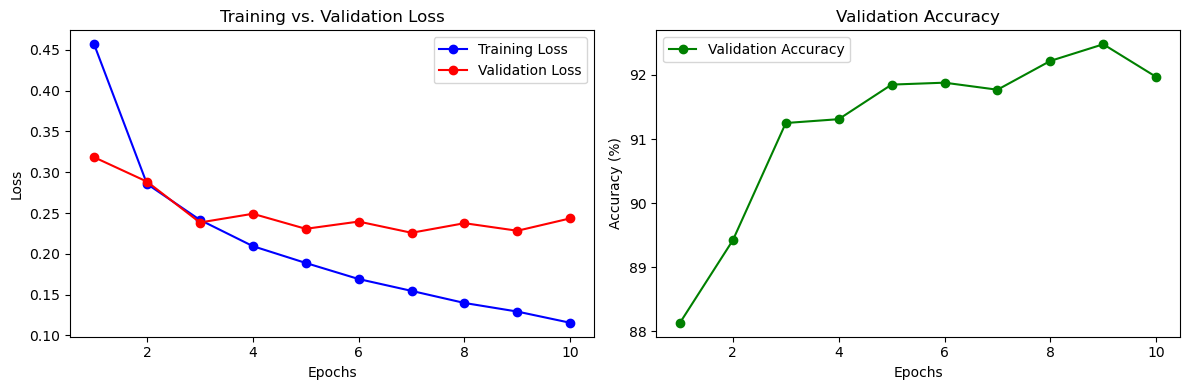

In [7]:
#get run time
start_time = time.time()

train_losses, val_losses, accuracies = train(cnnnet, optimizer,torch.nn.CrossEntropyLoss(), train_data_loader,val_data_loader, epochs=10, device=device)

end_time = time.time()
elapsed_time = end_time - start_time

print(f"Total Training Time: {elapsed_time:.2f} seconds (~{elapsed_time/60:.2f} minutes)")

# Visualization of Training and Validation Losses and Accuracy
epochs = range(1, 11)  

plt.figure(figsize=(12, 4))

# Training and Validation Loss
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, 'bo-', label='Training Loss')
plt.plot(epochs, val_losses, 'ro-', label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs. Validation Loss')
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, accuracies, 'go-', label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.title('Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [8]:
# Saving the trained model's state_dict (model parameters)
torch.save(cnnnet.state_dict(), "MNIST_fash_CNN_model.pth")

In [9]:
# Saving entire
torch.save(cnnnet, "MNIST_fash_full_model.pth")

In [13]:
#!pip install psutil

In [10]:
import psutil

#print the CPU usage
def print_cpu_usage(label=""):
    cpu_usage = psutil.cpu_percent(interval=1)
    print(f"{label} CPU Usage: {cpu_usage}%")

# Print CPU usage before DataParallel
print_cpu_usage("Before DataParallel:")

# Defining model
cnnnet = CNNNet()

# Getting DataParallel to use all available CPU cores
model = nn.DataParallel(cnnnet)

# Print CPU usage after DataParallel
print_cpu_usage("After DataParallel:")


Before DataParallel: CPU Usage: 10.9%
After DataParallel: CPU Usage: 4.3%


### Training model with DataParallel
Visualising to see if accuracy/loss improves etc.

In [17]:
# Loading the pre-trained model
cnnnet = CNNNet()  # Create a new instance of the original CNNNet class
cnnnet.load_state_dict(torch.load("MNIST_fash_CNN_model.pth"))  # Load the model's state_dict

# Move the model to the device (CPU)
cnnnet.to(device)

# Apply Data Parallel
model_parallel = nn.DataParallel(cnnnet)

# Re-define optimizer for the DataParallel model
optimizer_parallel = torch.optim.Adam(model_parallel.parameters(), lr=0.001, weight_decay=1e-4)


In [18]:
# Training with DataParallel
start_time_parallel = time.time()
train_losses_parallel, val_losses_parallel, accuracies_parallel = train(model_parallel, optimizer_parallel, torch.nn.CrossEntropyLoss(), train_data_loader, val_data_loader, epochs=10, device=device)
end_time_parallel = time.time()
elapsed_time_parallel = end_time_parallel - start_time_parallel
print(f"Training with DataParallel took {elapsed_time_parallel:.2f} seconds")

Epoch 1/10 | Training Loss: 0.11 | Validation Loss: 0.25 | Accuracy: 92.09%
Epoch 2/10 | Training Loss: 0.10 | Validation Loss: 0.27 | Accuracy: 92.00%
Epoch 3/10 | Training Loss: 0.09 | Validation Loss: 0.26 | Accuracy: 92.30%
Epoch 4/10 | Training Loss: 0.09 | Validation Loss: 0.27 | Accuracy: 92.18%
Epoch 5/10 | Training Loss: 0.08 | Validation Loss: 0.25 | Accuracy: 92.27%
Epoch 6/10 | Training Loss: 0.08 | Validation Loss: 0.28 | Accuracy: 92.18%
Epoch 7/10 | Training Loss: 0.07 | Validation Loss: 0.29 | Accuracy: 92.35%
Epoch 8/10 | Training Loss: 0.07 | Validation Loss: 0.31 | Accuracy: 92.13%
Epoch 9/10 | Training Loss: 0.07 | Validation Loss: 0.36 | Accuracy: 91.20%
Epoch 10/10 | Training Loss: 0.07 | Validation Loss: 0.28 | Accuracy: 92.49%
Training with DataParallel took 6303.29 seconds


This time may have been effected by VM sleeping when I worked on other models in my Windows machine.

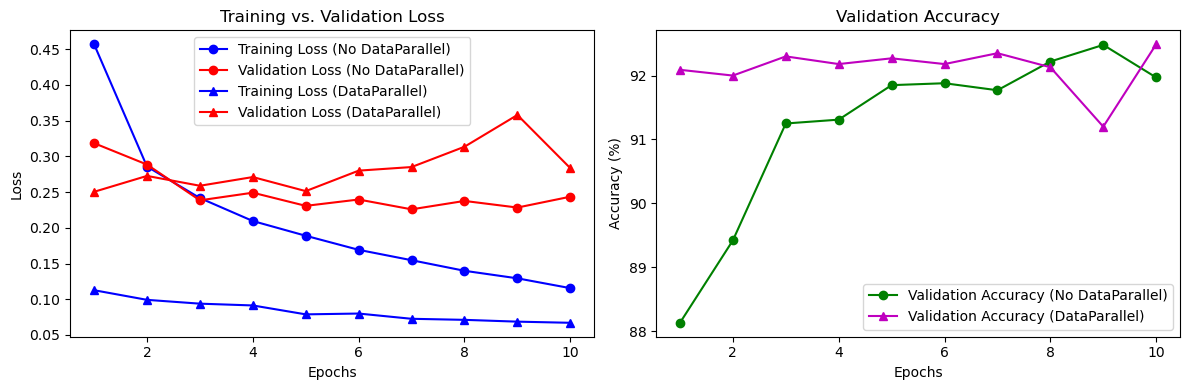

In [19]:
# Visualization of Training and Validation Losses and Accuracy (Comparison)
epochs = range(1, 11)

plt.figure(figsize=(12, 4))

# Training and Validation Loss
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, 'bo-', label='Training Loss (No DataParallel)')
plt.plot(epochs, val_losses, 'ro-', label='Validation Loss (No DataParallel)')
plt.plot(epochs, train_losses_parallel, 'b^-', label='Training Loss (DataParallel)')
plt.plot(epochs, val_losses_parallel, 'r^-', label='Validation Loss (DataParallel)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs. Validation Loss')
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, accuracies, 'go-', label='Validation Accuracy (No DataParallel)')
plt.plot(epochs, accuracies_parallel, 'm^-', label='Validation Accuracy (DataParallel)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.title('Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [20]:
# Save the DataParallel trained model's state_dict
torch.save(model_parallel.state_dict(), "MNIST_fash_CNN_DataParallel_model.pth")

Data Parallel may not speed up model due to overheads involved with splitting data to CPUs which will not get compensated by being transferred to numerous GPUs as I only have a handful of CPUs at my disposal... Am showing ability to use Data parallelism... but my machine constrants will not enable the full benefit to be shown

Can however, even after the firsst epoch, see that the accuracy is already higher than before - this may be due to the stochastic nature of data... or that the process of splitting the data over multiple CPUS has made the model more efficient enabling it to converge faster